In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_average_cm(base_path, seeds, filename_template):
    all_cms = []
    labels = None

    for seed in seeds:
        filename = filename_template.format(seed=seed)
        full_path = os.path.join(base_path.lower(), filename)
        
        if os.path.exists(full_path):
            df = pd.read_csv(full_path)
            y_true = df['y_true']
            y_pred = df['y_pred']
            
            if labels is None:
                labels = sorted(list(set(y_true) | set(y_pred)))
            
            cm = confusion_matrix(y_true, y_pred, labels=labels)
            all_cms.append(cm)

    if not all_cms:
        print("Data tidak ditemukan.")
        return

    # --- Menghitung Rata-rata dan Pembulatan ---
    avg_cm = np.mean(all_cms, axis=0)
    
    # Membulatkan ke integer terdekat
    avg_cm_int = np.rint(avg_cm).astype(int) 

    # --- Visualisasi ---
    plt.figure(figsize=(10, 8))
    # Gunakan fmt='d' karena sekarang datanya sudah integer
    sns.heatmap(avg_cm_int, annot=True, fmt='d', cmap='YlGnBu', 
                xticklabels=labels, yticklabels=labels)
    
    plt.title(f'Average Confusion Matrix (Rounded)\nSeeds: {seeds}')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.show()

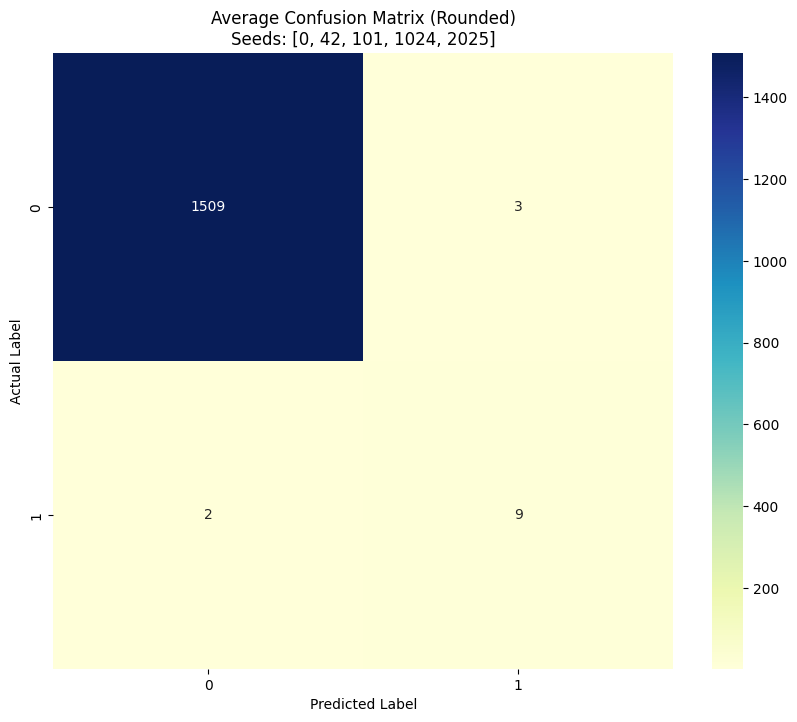

In [2]:
# NoOS + NoSCL
seeds = [0, 42, 101, 1024, 2025]
path = "/kaggle/input/eth-G1-MLP-NoOS-CSL/results/"
# Gunakan {seed} sebagai placeholder untuk nama file
template = "pred_first_graph_GraphSAGE_MLP_NoOS_CSL_{seed}.csv"

plot_average_cm(path, seeds, template)

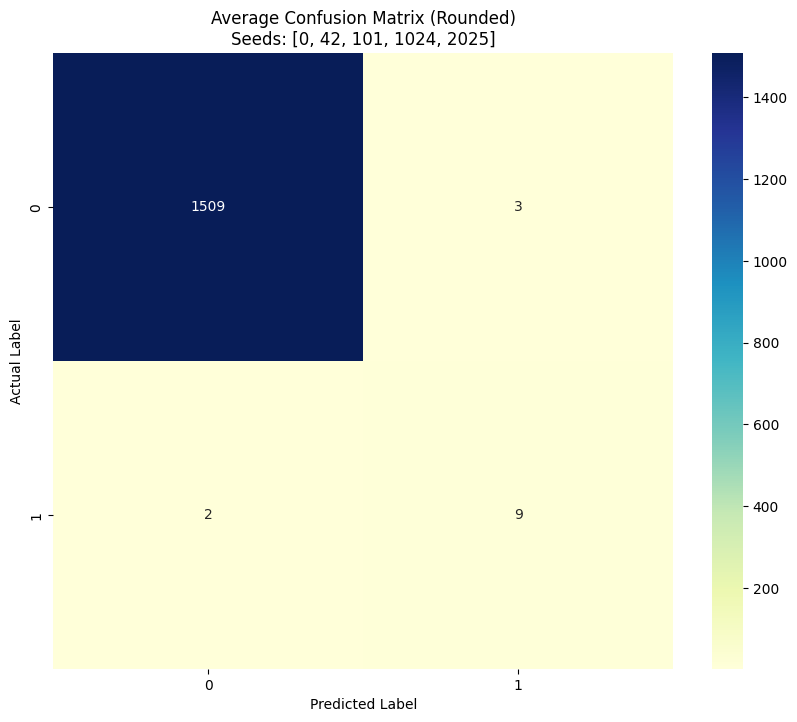

In [3]:
# NoOS + CSL
my_path = "/kaggle/input/eth-G1-MLP-NoOS-CSL/results/"
# Gunakan {seed} sebagai placeholder untuk nama file
template = "pred_first_graph_GraphSAGE_MLP_NoOS_CSL_{seed}.csv"

plot_average_cm(path, seeds, template)

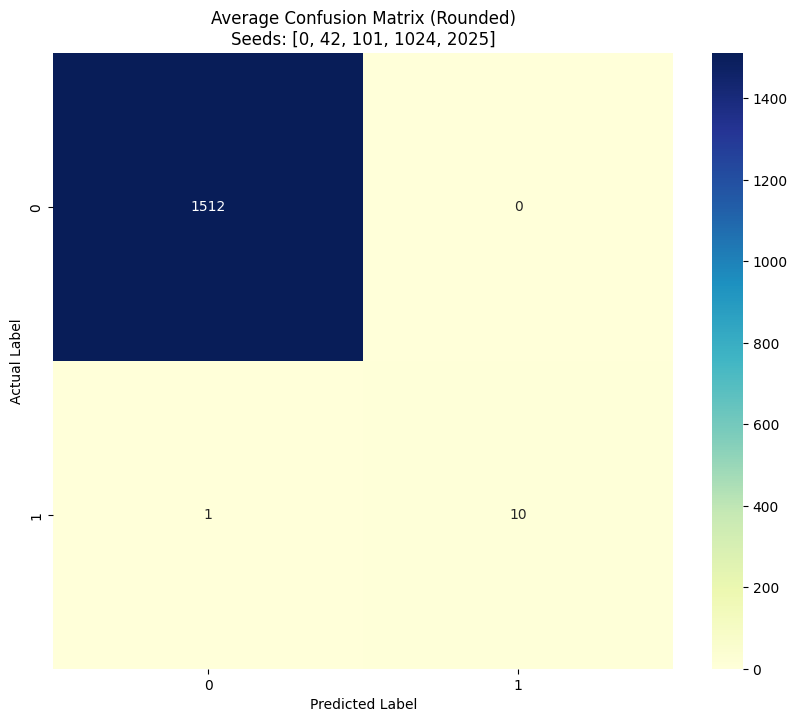

In [4]:
# GIN + WAGAN + NoCSL
path = "/kaggle/input/eth-G1-GNN-WACGAN-NoCSL/results/"
# Gunakan {seed} sebagai placeholder untuk nama file
template = "pred_first_graph_GIN_GIN_OS_NoCSL_{seed}.csv"

plot_average_cm(path, seeds, template)

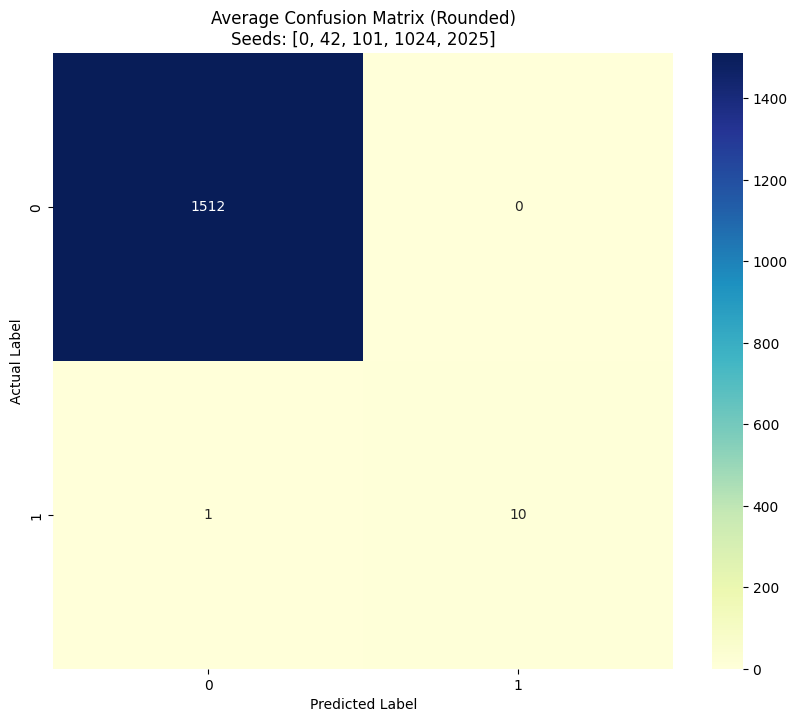

In [5]:
# GIN + WAGAN + CSL
path = "/kaggle/input/eth-G1-GNN-WACGAN-CSL/results/"
# Gunakan {seed} sebagai placeholder untuk nama file
template = "pred_first_graph_GIN_GIN_OS_CSL_{seed}.csv"

plot_average_cm(path, seeds, template)

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

seeds = [0, 42, 101, 1024, 2025]

def plot_cm_from_csv(base_path, filename, target_y_true='y_true', target_y_pred='y_pred'):
    """
    Fungsi untuk membaca CSV dan menampilkan Confusion Matrix.
    """
    full_path = os.path.join(base_path.lower(), filename)
    
    # Cek apakah file ada sebelum membaca
    if not os.path.exists(full_path):
        print(f"File tidak ditemukan: {full_path}")
        return

    # 1. Load data
    df = pd.read_csv(full_path)
    y_true = df[target_y_true]
    y_pred = df[target_y_pred]

    # 2. Hitung Matrix
    labels = sorted(list(set(y_true) | set(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # 3. Visualisasi
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels, annot_kws={"size": 18, "weight": "bold"})
    
    # plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label', fontsize=16)
    plt.ylabel('Actual Label', fontsize=16)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    # 4. Simpan gambar (nama file gambar otomatis mengikuti nama csv)
    save_name = filename.replace('.csv', '.png')
    plt.savefig(save_name)
    plt.show()

    # 5. Report
    print(f"\nClassification Report for: {filename}")
    print(classification_report(y_true, y_pred))
    print("-" * 50)

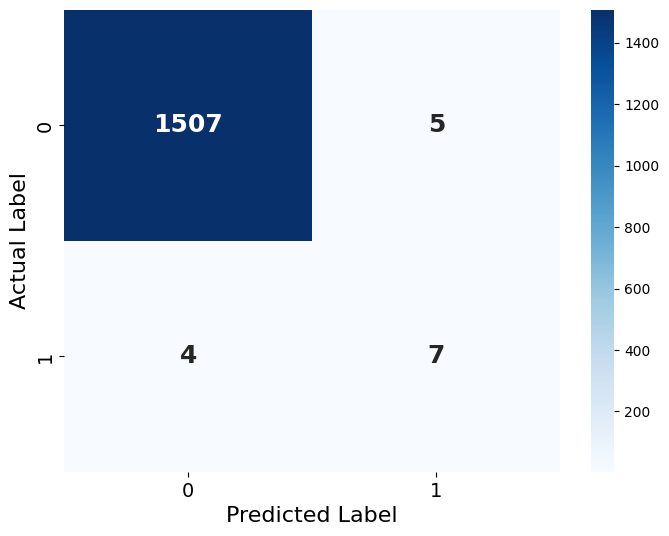


Classification Report for: pred_first_graph_GraphSAGE_MLP_NoOS_NoCSL_0.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       0.58      0.64      0.61        11

    accuracy                           0.99      1523
   macro avg       0.79      0.82      0.80      1523
weighted avg       0.99      0.99      0.99      1523

--------------------------------------------------


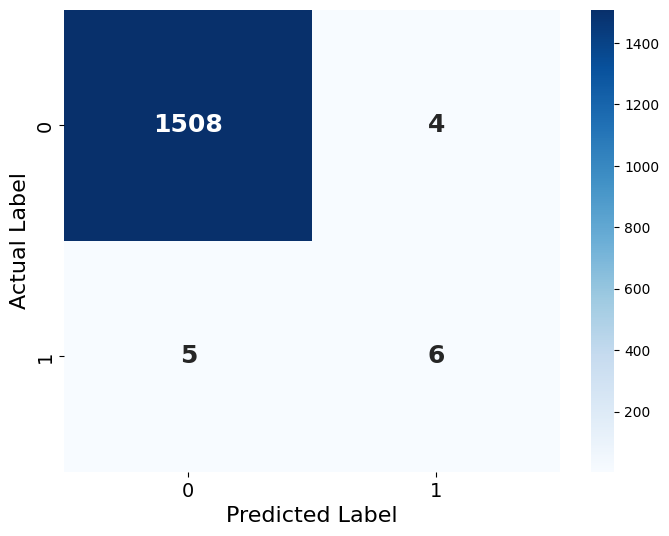


Classification Report for: pred_first_graph_GraphSAGE_MLP_NoOS_NoCSL_42.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       0.60      0.55      0.57        11

    accuracy                           0.99      1523
   macro avg       0.80      0.77      0.78      1523
weighted avg       0.99      0.99      0.99      1523

--------------------------------------------------


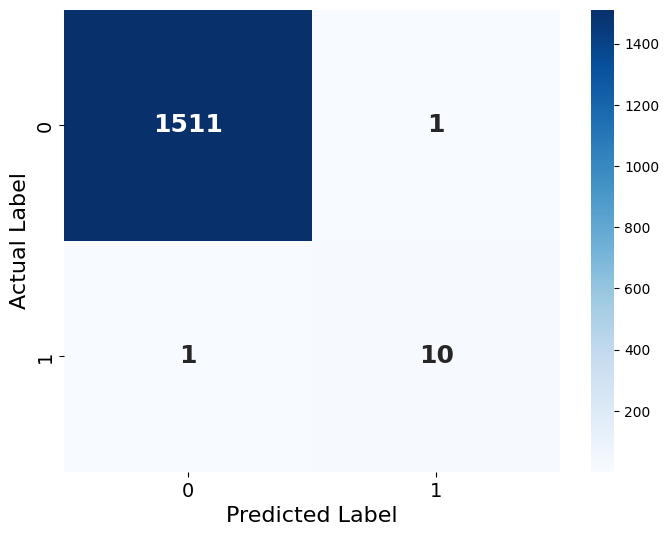


Classification Report for: pred_first_graph_GraphSAGE_MLP_NoOS_NoCSL_101.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       0.91      0.91      0.91        11

    accuracy                           1.00      1523
   macro avg       0.95      0.95      0.95      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


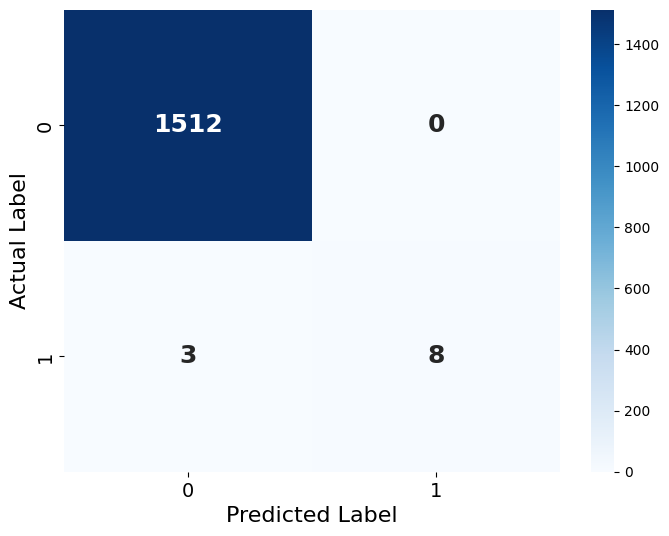


Classification Report for: pred_first_graph_GraphSAGE_MLP_NoOS_NoCSL_1024.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      0.73      0.84        11

    accuracy                           1.00      1523
   macro avg       1.00      0.86      0.92      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


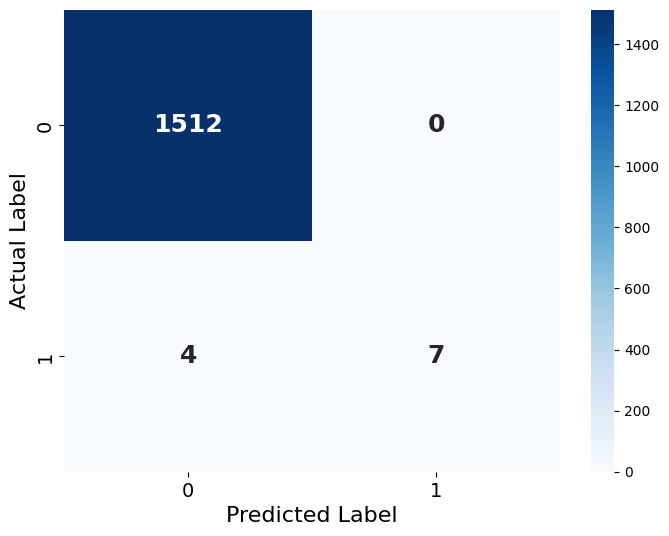


Classification Report for: pred_first_graph_GraphSAGE_MLP_NoOS_NoCSL_2025.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      0.64      0.78        11

    accuracy                           1.00      1523
   macro avg       1.00      0.82      0.89      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


In [7]:
# NoOS + NoSCL

my_path = "/kaggle/input/eth-G1-MLP-NoOS-NoCSL/results/"

# Loop memanggil fungsi
for ed in seeds:
    fname = f"pred_first_graph_GraphSAGE_MLP_NoOS_NoCSL_{ed}.csv"
    plot_cm_from_csv(base_path=my_path, filename=fname)

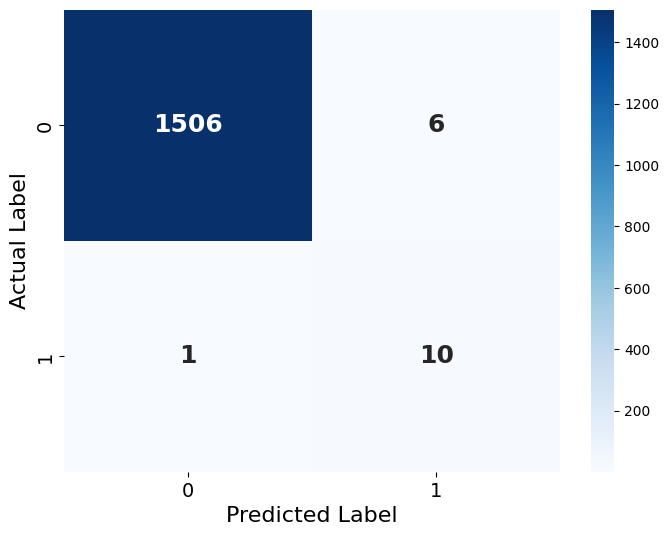


Classification Report for: pred_first_graph_GraphSAGE_MLP_NoOS_CSL_0.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       0.62      0.91      0.74        11

    accuracy                           1.00      1523
   macro avg       0.81      0.95      0.87      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


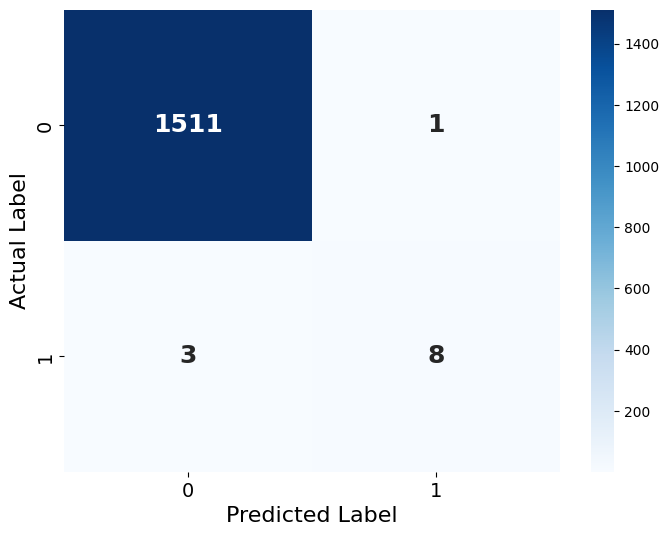


Classification Report for: pred_first_graph_GraphSAGE_MLP_NoOS_CSL_42.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       0.89      0.73      0.80        11

    accuracy                           1.00      1523
   macro avg       0.94      0.86      0.90      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


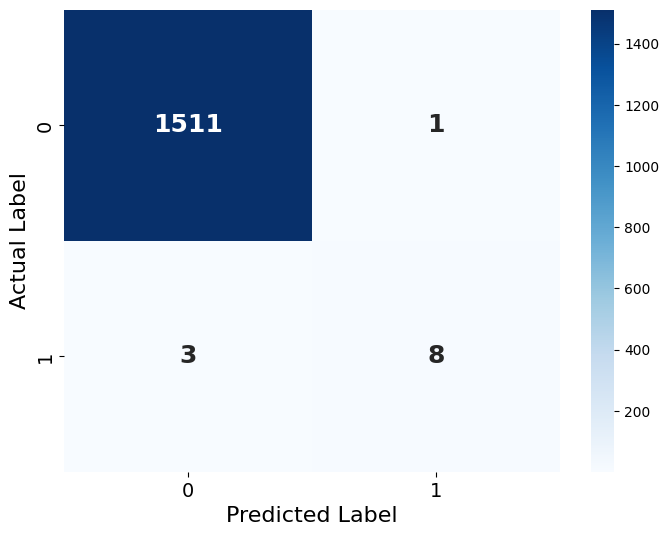


Classification Report for: pred_first_graph_GraphSAGE_MLP_NoOS_CSL_101.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       0.89      0.73      0.80        11

    accuracy                           1.00      1523
   macro avg       0.94      0.86      0.90      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


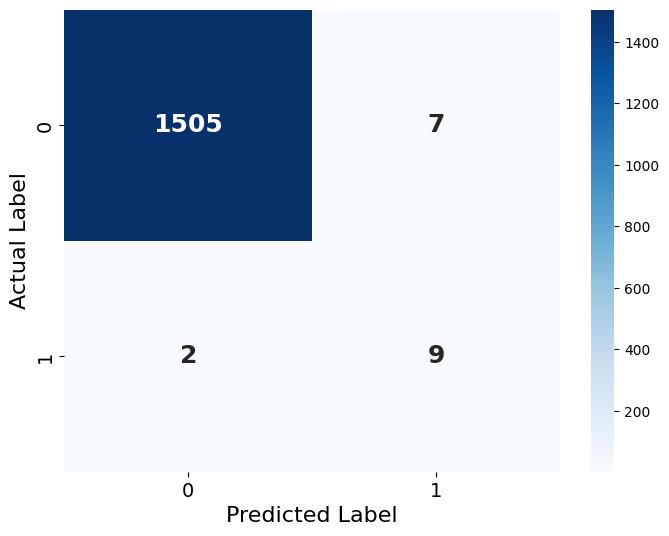


Classification Report for: pred_first_graph_GraphSAGE_MLP_NoOS_CSL_1024.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       0.56      0.82      0.67        11

    accuracy                           0.99      1523
   macro avg       0.78      0.91      0.83      1523
weighted avg       1.00      0.99      0.99      1523

--------------------------------------------------


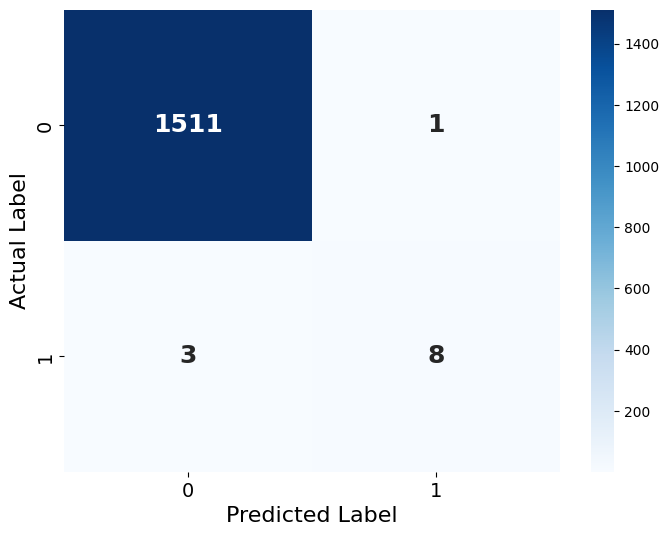


Classification Report for: pred_first_graph_GraphSAGE_MLP_NoOS_CSL_2025.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       0.89      0.73      0.80        11

    accuracy                           1.00      1523
   macro avg       0.94      0.86      0.90      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


In [8]:
# NoOS + CSL
seeds = [0, 42, 101, 1024, 2025]
my_path = "/kaggle/input/eth-G1-MLP-NoOS-CSL/results/"

# Loop memanggil fungsi
for ed in seeds:
    fname = f"pred_first_graph_GraphSAGE_MLP_NoOS_CSL_{ed}.csv"
    plot_cm_from_csv(base_path=my_path, filename=fname)

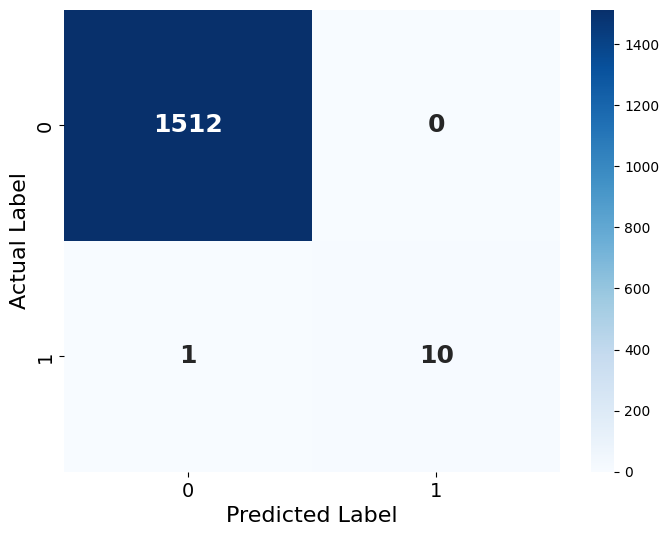


Classification Report for: pred_first_graph_GIN_GIN_OS_NoCSL_0.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      0.91      0.95        11

    accuracy                           1.00      1523
   macro avg       1.00      0.95      0.98      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


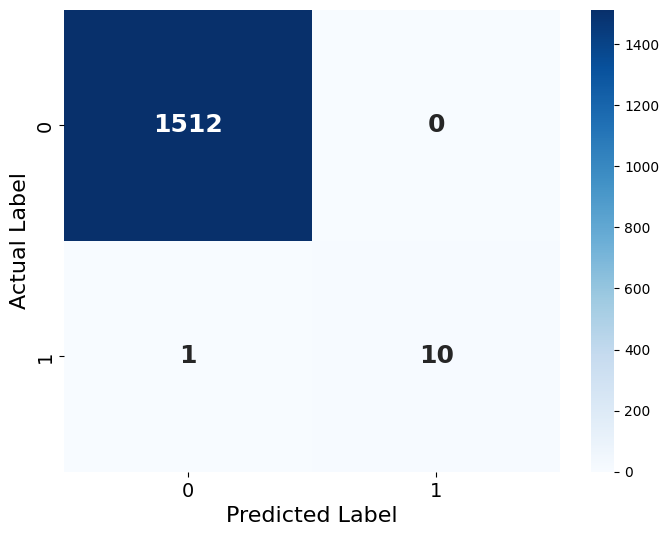


Classification Report for: pred_first_graph_GIN_GIN_OS_NoCSL_42.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      0.91      0.95        11

    accuracy                           1.00      1523
   macro avg       1.00      0.95      0.98      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


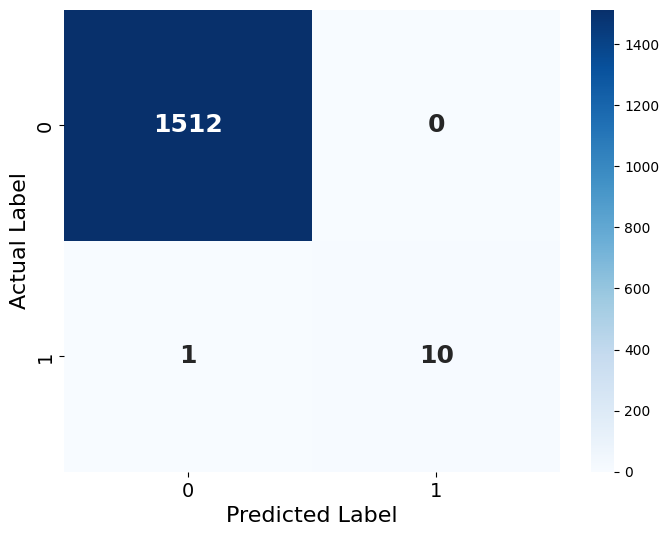


Classification Report for: pred_first_graph_GIN_GIN_OS_NoCSL_101.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      0.91      0.95        11

    accuracy                           1.00      1523
   macro avg       1.00      0.95      0.98      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


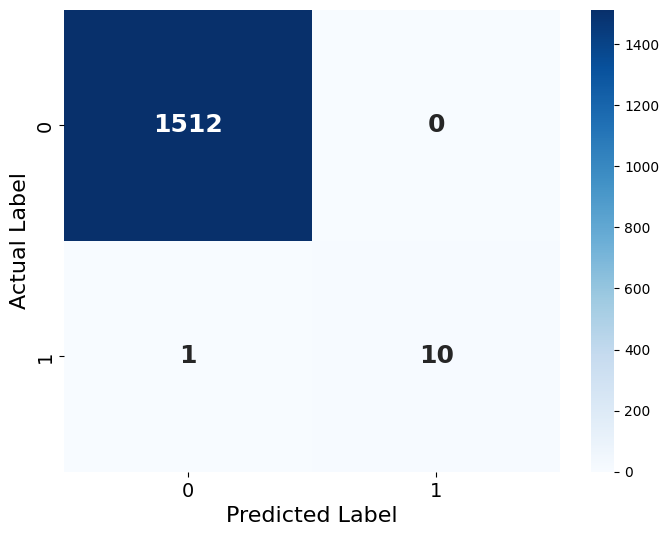


Classification Report for: pred_first_graph_GIN_GIN_OS_NoCSL_1024.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      0.91      0.95        11

    accuracy                           1.00      1523
   macro avg       1.00      0.95      0.98      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


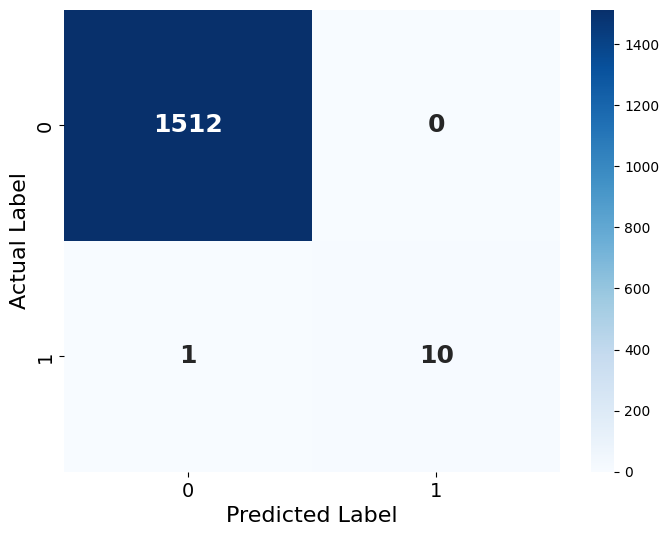


Classification Report for: pred_first_graph_GIN_GIN_OS_NoCSL_2025.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      0.91      0.95        11

    accuracy                           1.00      1523
   macro avg       1.00      0.95      0.98      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


In [9]:
# GIN + WAGAN + NoCSL
seeds = [0, 42, 101, 1024, 2025]
my_path = "/kaggle/input/eth-G1-GNN-WACGAN-NoCSL/results/"

# Loop memanggil fungsi
for ed in seeds:
    fname = f"pred_first_graph_GIN_GIN_OS_NoCSL_{ed}.csv"
    plot_cm_from_csv(base_path=my_path, filename=fname)

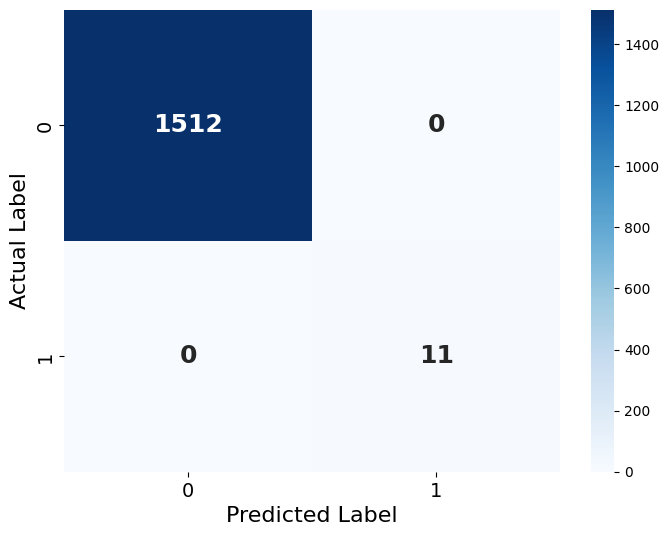


Classification Report for: pred_first_graph_GIN_GIN_OS_CSL_0.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      1.00      1.00        11

    accuracy                           1.00      1523
   macro avg       1.00      1.00      1.00      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


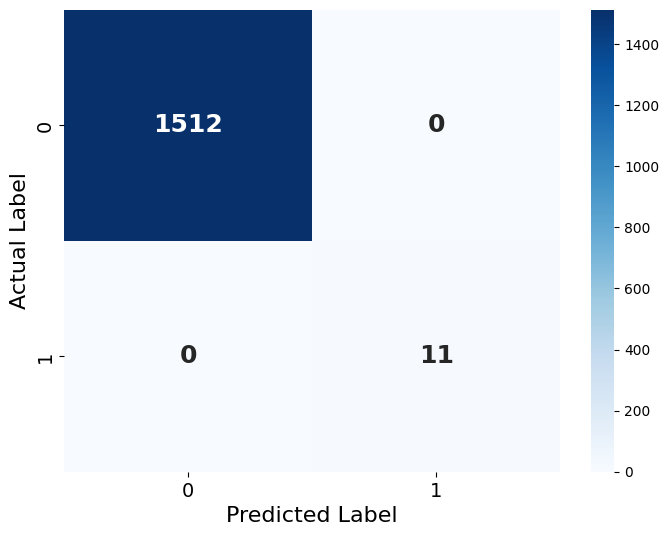


Classification Report for: pred_first_graph_GIN_GIN_OS_CSL_42.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      1.00      1.00        11

    accuracy                           1.00      1523
   macro avg       1.00      1.00      1.00      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


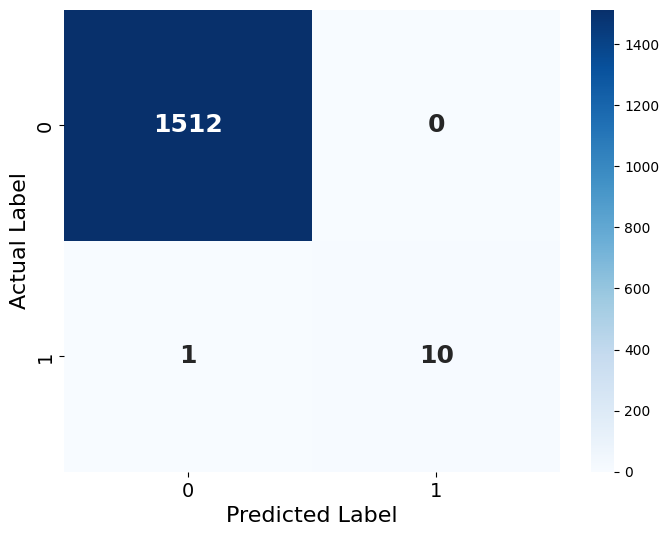


Classification Report for: pred_first_graph_GIN_GIN_OS_CSL_101.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      0.91      0.95        11

    accuracy                           1.00      1523
   macro avg       1.00      0.95      0.98      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


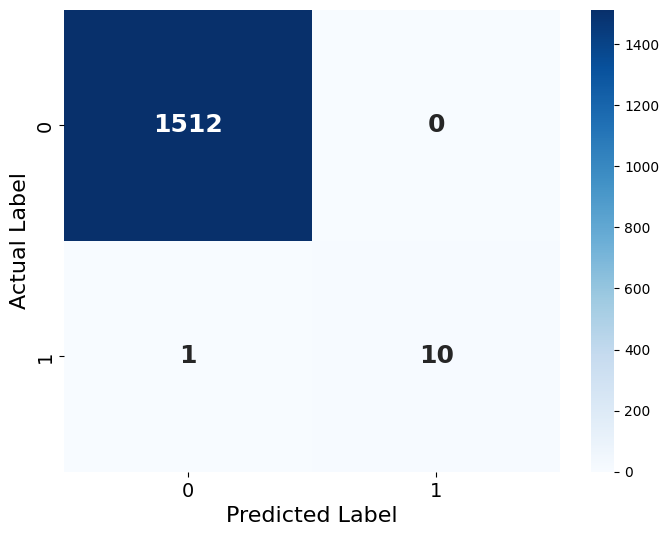


Classification Report for: pred_first_graph_GIN_GIN_OS_CSL_1024.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      0.91      0.95        11

    accuracy                           1.00      1523
   macro avg       1.00      0.95      0.98      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


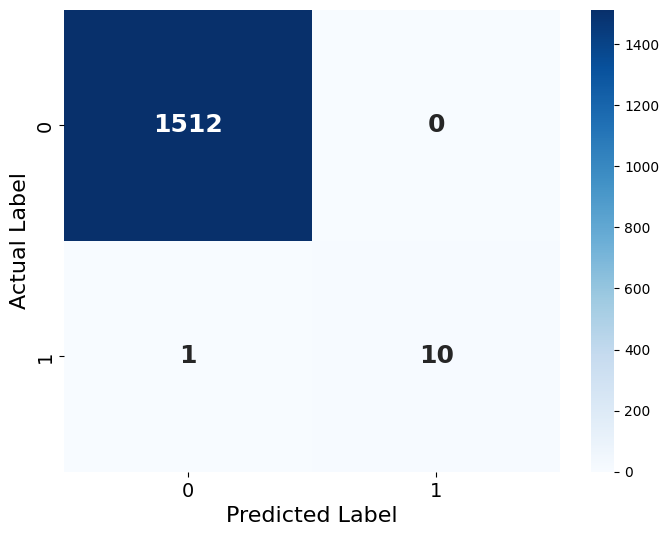


Classification Report for: pred_first_graph_GIN_GIN_OS_CSL_2025.csv
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      0.91      0.95        11

    accuracy                           1.00      1523
   macro avg       1.00      0.95      0.98      1523
weighted avg       1.00      1.00      1.00      1523

--------------------------------------------------


In [10]:
# GIN + WAGAN + CSL
seeds = [0, 42, 101, 1024, 2025]
my_path = "/kaggle/input/eth-G1-GNN-WACGAN-CSL/results/"

# Loop memanggil fungsi
for ed in seeds:
    fname = f"pred_first_graph_GIN_GIN_OS_CSL_{ed}.csv"
    plot_cm_from_csv(base_path=my_path, filename=fname)